# Gradient Analysis

---

## Part 1:

**Question 1: The Reusability Advantage**

Consider a simple MLP: $\mathbf{p} = W\mathbf{x}$, $\mathbf{q} = \phi(\mathbf{p})$, $s = \mathbf{u}^T \mathbf{q}$, $o = \phi(s)$, $L = (o - y)^2$.

When computing $\frac{\partial L}{\partial w_{11}}$ via the chain rule, we get:

$$\frac{\partial L}{\partial w_{11}} = \frac{\partial L}{\partial o} \cdot \frac{\partial o}{\partial s} \cdot \frac{\partial s}{\partial q_1} \cdot \frac{\partial q_1}{\partial p_1} \cdot \frac{\partial p_1}{\partial w_{11}}$$

Why is computing gradients **backward** (from $L$ toward $\mathbf{x}$) more efficient than computing each weight's gradient independently from scratch?

A) Because backward computation uses smaller numbers, avoiding numerical overflow  
B) Because intermediate terms like $\frac{\partial L}{\partial o} \cdot \frac{\partial o}{\partial s}$ are shared across multiple weight gradients and only need to be computed once  
C) Because the chain rule only works in the backward direction  
D) Because backward computation avoids the need for activation function derivatives  

#### Answer:
B) Because intermediate terms like $\frac{\partial L}{\partial o} \cdot \frac{\partial o}{\partial s}$ are shared across many parameter gradients, backprop computes these shared derivatives once and reuses them, making it far more efficient than recomputing each gradient independently.

**Question 2: Zero and Equal Initialization**

Consider a fully connected neural network with multiple hidden layers, each having more than one neuron, and using a symmetric activation function such as $\tanh$.

Which of the following statements is **true** about weight initialization?

A) Initializing all weights to zero is fine because the gradients will break symmetry after the first update  
B) Initializing all weights to the same non-zero constant is fine because different inputs will produce different gradients  
C) Both zero initialization and equal-constant initialization cause all neurons in a layer to compute identical outputs and receive identical gradient updates, so symmetry is never broken  
D) Zero initialization causes vanishing gradients, but equal-constant initialization does not  

#### Answer:
C) Both zero initialization and equal-constant initialization cause all neurons in the same layer to remain identical, so they produce the same activations and receive the same updates; symmetry is not broken and the layer cannot learn diverse features.

---

## Part 2: The Arithmetic of Gradients

**Question 3: Manual Gradient Computation**

**Scenario:**

Consider the following tiny MLP with **sigmoid** activation $\sigma(z) = \frac{1}{1 + e^{-z}}$ and MSE loss $L = (o - y)^2$:

$$p_1 = w_{11} x_1 + w_{12} x_2$$
$$q_1 = \sigma(p_1)$$
$$o = u_1 \cdot q_1$$
$$L = (o - y)^2$$

Given:  
- $x_1 = 1,\; x_2 = 2$  
- $w_{11} = 0.5,\; w_{12} = -0.5$  
- $u_1 = 1.0$  
- $y = 1$  

**Recall:** $\sigma'(z) = \sigma(z)(1 - \sigma(z))$

**Task:**

1. Compute the forward pass: $p_1$, $q_1$, $o$, and $L$.  
2. Compute $\frac{\partial L}{\partial u_1}$ and $\frac{\partial L}{\partial w_{11}}$ using the chain rule.

*Show your steps below.*

#### Your Solution:
1) Forward pass  
$p_1 = 0.5(1) + (-0.5)(2) = -0.5$  
$q_1 = \sigma(-0.5) = \frac{1}{1+e^{0.5}} \approx 0.37754067$  
$o = u_1 q_1 = 1.0 \cdot 0.37754067 = 0.37754067$  
$L = (o-y)^2 = (0.37754067-1)^2 \approx 0.38745562$

2) Gradients  
$\frac{\partial L}{\partial u_1} = \frac{\partial L}{\partial o}\frac{\partial o}{\partial u_1} = 2(o-y)\,q_1$  
$= 2(-0.62245933)(0.37754067) \approx -0.47000742$

$\frac{\partial L}{\partial w_{11}} = \frac{\partial L}{\partial o}\frac{\partial o}{\partial q_1}\frac{\partial q_1}{\partial p_1}\frac{\partial p_1}{\partial w_{11}}$  
$= 2(o-y)\cdot u_1 \cdot q_1(1-q_1) \cdot x_1$  
$= 2(-0.62245933)\cdot 1 \cdot (0.37754067)(0.62245933) \cdot 1 \approx -0.29256051$

**Question 4: Vanishing Gradient Intuition**

**Scenario:**

A network has $D$ layers, each applying: $h^{(l)} = \sigma(W^{(l)} h^{(l-1)})$.

The gradient of the loss w.r.t. a weight in layer $l$ involves a product of $D - l$ terms of the form $\sigma'(\cdot) \cdot W^{(\cdot)}$.

The maximum value of $\sigma'(z)$ for the sigmoid function is $0.25$ (at $z = 0$).

**Task:**

If $D = 10$ and you are computing the gradient for layer $l = 1$ (the first layer), you need to multiply through $9$ such terms. Assuming each $\sigma'(\cdot) = 0.25$ and each $|w| = 1$:

1. What is the magnitude of the gradient scaling factor at layer 1?  
2. Explain in one sentence why this is problematic for training deep networks with sigmoid activations.

#### Your Solution:
1) Scaling factor  
$$(0.25 \cdot 1)^9 = 0.25^9 = \frac{1}{4^9} = \frac{1}{262144} \approx 3.8147 \times 10^{-6}$$

2) Why problematic  
This tiny factor makes early-layer gradients almost zero, so those layers update extremely slowly and the network struggles to learn useful deep representations.

---

## Part 3: Coding Challenge

In this section, you will implement the **forward pass** and **backward pass (backpropagation)** for a simple 2-layer MLP from scratch using only NumPy.

The network architecture is:

$$\mathbf{p} = W_1 \mathbf{x}$$
$$\mathbf{q} = \sigma(\mathbf{p})$$
$$s = \mathbf{w}_2^T \mathbf{q}$$
$$o = \sigma(s)$$
$$L = (o - y)^2$$

where $\sigma$ is the sigmoid activation.

**You are required to:**  
**A) Fill in `forward_pass`** — compute all intermediate values and the loss  
**B) Fill in `backward_pass`** — compute gradients of the loss w.r.t. all weights using the chain rule

In [47]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [48]:
# ----- Activation function -----
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

In [49]:
# ----- Generate synthetic data (XOR-like problem) -----
# 4 samples, 2 features each
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)

# XOR labels
Y = np.array([0, 1, 1, 0], dtype=float)

print("Dataset (XOR):")
for i in range(len(X)):
    print(f"  x = {X[i]}  ->  y = {Y[i]}")

Dataset (XOR):
  x = [0. 0.]  ->  y = 0.0
  x = [0. 1.]  ->  y = 1.0
  x = [1. 0.]  ->  y = 1.0
  x = [1. 1.]  ->  y = 0.0


In [50]:
# ----- Network parameters -----
# Layer 1: W1 is (hidden_dim x input_dim), b1 is (hidden_dim,)
# Layer 2: w2 is (hidden_dim,), b2 is scalar

hidden_dim = 4
input_dim = 2

W1 = np.random.randn(hidden_dim, input_dim) * 0.5
b1 = np.zeros(hidden_dim)
w2 = np.random.randn(hidden_dim) * 0.5
b2 = 0.0

print(f"W1 shape: {W1.shape}")
print(f"b1 shape: {b1.shape}")
print(f"w2 shape: {w2.shape}")
print(f"b2: {b2}")

W1 shape: (4, 2)
b1 shape: (4,)
w2 shape: (4,)
b2: 0.0


In [51]:
def forward_pass(x, y, W1, b1, w2, b2):
    """
    Compute the forward pass for a single sample.
    
    Network:
        p = W1 @ x + b1          (pre-activation, hidden layer)
        q = sigmoid(p)            (post-activation, hidden layer)
        s = w2 @ q + b2           (pre-activation, output)
        o = sigmoid(s)            (output prediction)
        L = (o - y)^2             (MSE loss for one sample)
    
    Args:
        x: input vector, shape (input_dim,)
        y: scalar target label
        W1: weight matrix, shape (hidden_dim, input_dim)
        b1: bias vector, shape (hidden_dim,)
        w2: weight vector, shape (hidden_dim,)
        b2: scalar bias
    
    Returns:
        cache: dict with keys 'x', 'y', 'p', 'q', 's', 'o', 'L'
    """
    p = W1 @ x + b1
    q = sigmoid(p)
    s = w2 @ q + b2
    o = sigmoid(s)
    L = (o - y) ** 2

    return {
        'x': x,
        'y': y,
        'p': p,
        'q': q,
        's': s,
        'o': o,
        'L': L,
    }

In [52]:
def backward_pass(cache, W1, b1, w2, b2):
    """
    Compute gradients of L w.r.t. all parameters using backpropagation.
    
    Use the chain rule, propagating gradients backward:
        dL/do = 2(o - y)
        dL/ds = dL/do * sigmoid'(s)
        dL/dw2 = dL/ds * q           (since s = w2 @ q + b2)
        dL/db2 = dL/ds
        dL/dq = dL/ds * w2
        dL/dp = dL/dq * sigmoid'(p)   (element-wise)
        dL/dW1 = outer(dL/dp, x)      (since p = W1 @ x + b1)
        dL/db1 = dL/dp
    
    Args:
        cache: dict from forward_pass with 'x', 'y', 'p', 'q', 's', 'o', 'L'
        W1, b1, w2, b2: current network parameters
    
    Returns:
        grads: dict with keys 'dW1', 'db1', 'dw2', 'db2'
    """
    x = cache['x']
    y = cache['y']
    p = cache['p']
    q = cache['q']
    s = cache['s']
    o = cache['o']

    dL_do = 2 * (o - y)
    dL_ds = dL_do * sigmoid_derivative(s)
    dL_dw2 = dL_ds * q
    dL_db2 = dL_ds
    dL_dq = dL_ds * w2
    dL_dp = dL_dq * sigmoid_derivative(p)
    dL_dW1 = np.outer(dL_dp, x)
    dL_db1 = dL_dp

    return {
        'dW1': dL_dW1,
        'db1': dL_db1,
        'dw2': dL_dw2,
        'db2': dL_db2,
    }

In [ ]:
# ----- Training loop -----
lr = 1.0
epochs = 5000
loss_history = []

for epoch in range(epochs):
    total_loss = 0.0
    dW1_acc = np.zeros_like(W1)
    db1_acc = np.zeros_like(b1)
    dw2_acc = np.zeros_like(w2)
    db2_acc = 0.0
    
    for i in range(len(X)):
        # Forward
        cache = forward_pass(X[i], Y[i], W1, b1, w2, b2)
        total_loss += cache['L']
        
        # Backward
        grads = backward_pass(cache, W1, b1, w2, b2)
        dW1_acc += grads['dW1']
        db1_acc += grads['db1']
        dw2_acc += grads['dw2']
        db2_acc += grads['db2']
    
    # Average gradients over batch
    N = len(X)
    W1 -= lr * dW1_acc / N
    b1 -= lr * db1_acc / N
    w2 -= lr * dw2_acc / N
    b2 -= lr * db2_acc / N
    
    avg_loss = total_loss / N
    loss_history.append(avg_loss)
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss: {avg_loss:.6f}")

Epoch     0 | Loss: 0.252779
Epoch   500 | Loss: 0.207992
Epoch  1000 | Loss: 0.023761
Epoch  1500 | Loss: 0.005800
Epoch  2000 | Loss: 0.002973
Epoch  2500 | Loss: 0.001939
Epoch  3000 | Loss: 0.001419
Epoch  3500 | Loss: 0.001111
Epoch  4000 | Loss: 0.000909
Epoch  4500 | Loss: 0.000767
Epoch  5000 | Loss: 0.000662
Epoch  5500 | Loss: 0.000581
Epoch  6000 | Loss: 0.000517
Epoch  6500 | Loss: 0.000466
Epoch  7000 | Loss: 0.000423
Epoch  7500 | Loss: 0.000387
Epoch  8000 | Loss: 0.000357
Epoch  8500 | Loss: 0.000331
Epoch  9000 | Loss: 0.000308
Epoch  9500 | Loss: 0.000289
Epoch 10000 | Loss: 0.000271
Epoch 10500 | Loss: 0.000256
Epoch 11000 | Loss: 0.000242
Epoch 11500 | Loss: 0.000229
Epoch 12000 | Loss: 0.000218
Epoch 12500 | Loss: 0.000208
Epoch 13000 | Loss: 0.000198
Epoch 13500 | Loss: 0.000190
Epoch 14000 | Loss: 0.000182
Epoch 14500 | Loss: 0.000174
Epoch 15000 | Loss: 0.000168
Epoch 15500 | Loss: 0.000161
Epoch 16000 | Loss: 0.000156
Epoch 16500 | Loss: 0.000150
Epoch 17000 | 

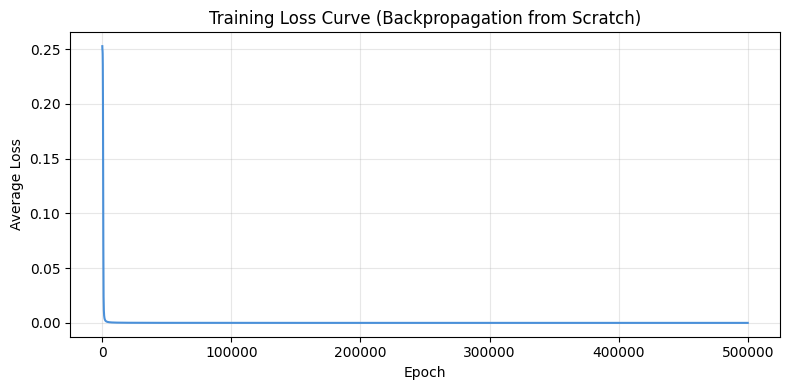

In [54]:
# ----- Plot training loss -----
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='#4A90D9', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Curve (Backpropagation from Scratch)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

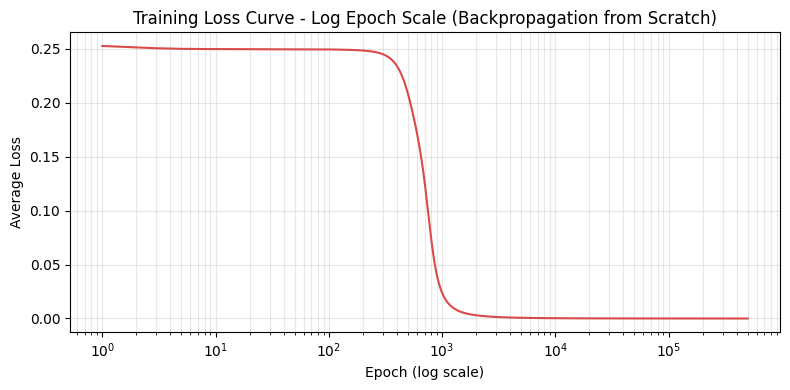

In [55]:
# ----- Plot training loss with only epoch on log scale -----
plt.figure(figsize=(8, 4))
plt.semilogx(range(1, len(loss_history) + 1), loss_history, color='#D94A4A', linewidth=1.5)
plt.xlabel('Epoch (log scale)')
plt.ylabel('Average Loss')
plt.title('Training Loss Curve - Log Epoch Scale (Backpropagation from Scratch)')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [56]:
# ----- Evaluate predictions -----
print("\nFinal Predictions:")
print("-" * 40)
for i in range(len(X)):
    cache = forward_pass(X[i], Y[i], W1, b1, w2, b2)
    pred = cache['o']
    print(f"  x = {X[i]}  |  y = {Y[i]:.0f}  |  pred = {pred:.4f}  |  rounded = {round(pred)}")

print("\nIf your forward and backward passes are correct,")
print("the predictions should closely match the XOR labels.")


Final Predictions:
----------------------------------------
  x = [0. 0.]  |  y = 0  |  pred = 0.0023  |  rounded = 0
  x = [0. 1.]  |  y = 1  |  pred = 0.9981  |  rounded = 1
  x = [1. 0.]  |  y = 1  |  pred = 0.9981  |  rounded = 1
  x = [1. 1.]  |  y = 0  |  pred = 0.0017  |  rounded = 0

If your forward and backward passes are correct,
the predictions should closely match the XOR labels.


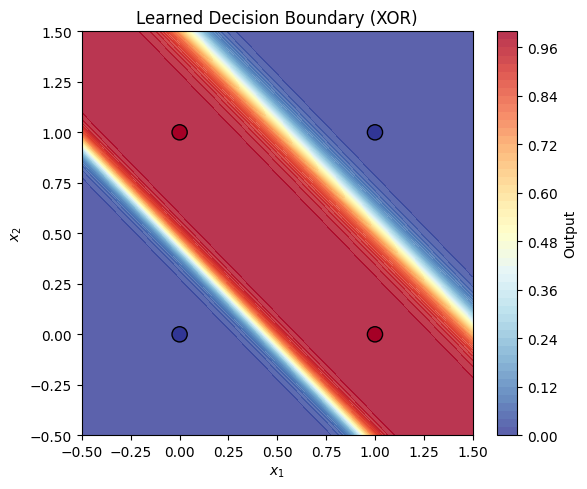

In [57]:
# ----- Visualize the learned decision boundary -----
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

Z = []
for pt in grid:
    cache = forward_pass(pt, 0, W1, b1, w2, b2)
    Z.append(cache['o'])
Z = np.array(Z).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, levels=50, cmap='RdYlBu_r', alpha=0.8)
plt.colorbar(label='Output')
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='RdYlBu_r', edgecolors='k', s=120, zorder=5)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Learned Decision Boundary (XOR)')
plt.tight_layout()
plt.show()